In [2]:
%matplotlib inline
import matplotlib.pyplot as plt
import sigpy as sp
import pandas as pd
import sigpy.plot as pl
import numpy as np
import os
ksp = np.load(r"/Users/ayman/Library/CloudStorage/OneDrive-King'sCollegeLondon/Project/Sigpytutorial/projection_ksp.npy")
coord = np.load(r"/Users/ayman/Library/CloudStorage/OneDrive-King'sCollegeLondon/Project/Sigpytutorial/projection_coord.npy")


import sys
from pathlib import Path

project_root = Path.cwd().parents[0]
sys.path.append(str(project_root))

import aymansigmri as asm

In [2]:
zte_radial_kspace, zte_radial_coords = asm.generate_zte_data_OLD(ksp=ksp, coord=coord, n_missing=0, undersampling_factor=1)

kspace_cart_coils = asm.gridding_operator(kspace_data=zte_radial_kspace, coord=zte_radial_coords)

onecoil_cart = kspace_cart_coils[0]
onecoil_cart.shape

(256, 256)

## Goal: Perform sliding window across one coil of the gridded data

[[ 1  2  3  4  5  6]
 [ 7  8  9 10 11 12]
 [13 14 15 16 17 18]
 [19 20 21 22 23 24]
 [25 26 27 28 29 30]
 [31 32 33 34 35 36]]


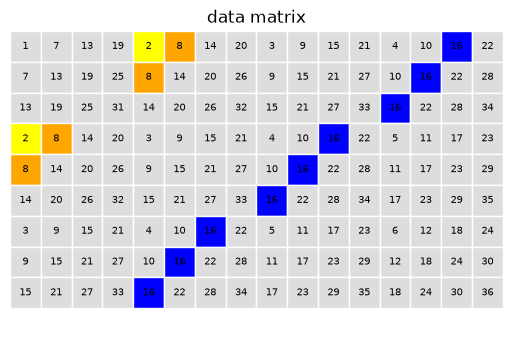

In [3]:
import numpy as np

arr = np.arange(1, 37).reshape(6, 6)
print(arr)
window_shape = (3, 3)


w = 3
data = np.empty((w*w,0))
N_x = arr.shape[0] - w + 1
N_y = arr.shape[1] - w + 1


x = 0
y = 0


for i in range(N_y):        
    for j in range(N_x):    
        mat = arr[x:x+w, y:y+w]
        col = mat.T.reshape(-1)
        data = np.column_stack((data, col))
        x += 1
    x = 0
    y += 1

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches


special = {2: 'yellow', 8: 'orange', 16: 'blue'}

fig, ax = plt.subplots(figsize=(10, 4))

ax.set_title('data matrix')
for r in range(data.shape[0]):
    for c in range(data.shape[1]):
        v = int(data[r, c])
        ax.add_patch(plt.Rectangle((c, -r), 1, 1, color=special.get(v, '#ddd'), ec='white'))
        ax.text(c+0.5, -r+0.5, str(v), ha='center', va='center', fontsize=7)
ax.set_xlim(0, data.shape[1])
ax.set_ylim(-data.shape[0], 1)
ax.set_aspect('equal')
ax.axis('off')

plt.show()


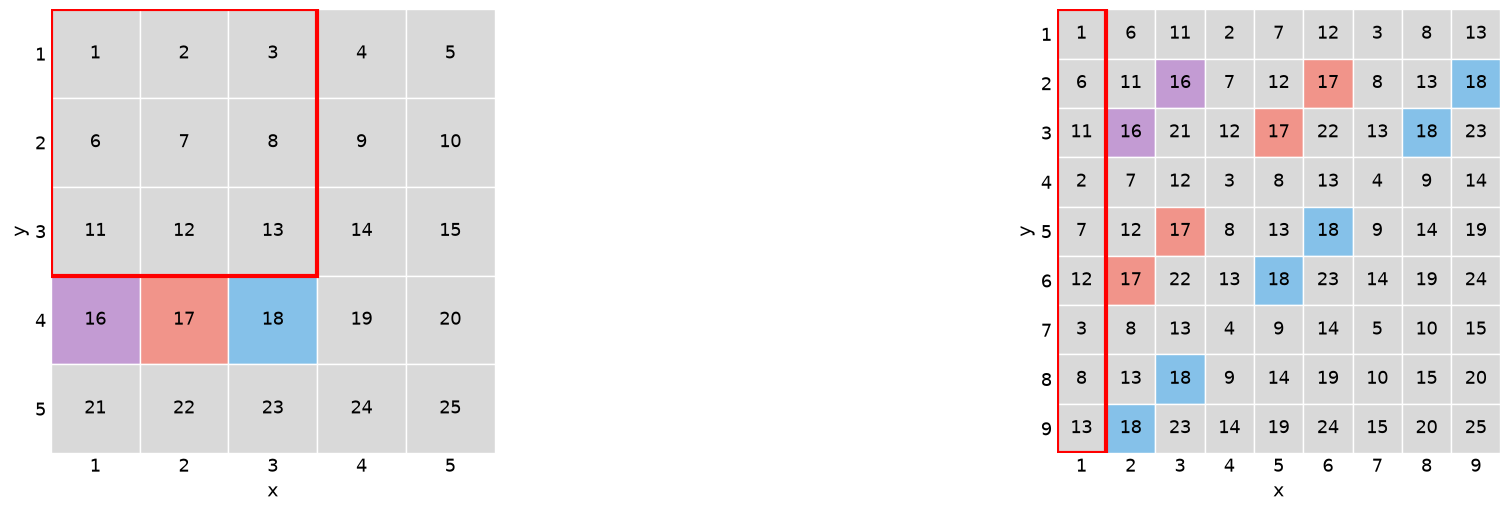

In [20]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Rectangle

# -----------------------------
# Build original array
# -----------------------------
arr = np.arange(1, 26).reshape(5, 5)

# -----------------------------
# Build Hankel-lifted matrix
# -----------------------------
w = 3
data = np.empty((w * w, 0), dtype=int)

N_x = arr.shape[0] - w + 1
N_y = arr.shape[1] - w + 1

x = 0
y = 0

for i in range(N_y):
    for j in range(N_x):
        mat = arr[x:x + w, y:y + w]
        col = mat.T.reshape(-1)
        data = np.column_stack((data, col))
        x += 1
    x = 0
    y += 1

# -----------------------------
# Plotting helper
# -----------------------------
highlight = {
    16:  "#c39bd3",
    17:  "#f1948a",
    18:  "#85c1e9"
}
black_cells = {}
def draw_matrix(ax, M, title, default_color="#d9d9d9", boxes=None):
    nrows, ncols = M.shape

    for r in range(nrows):
        for c in range(ncols):
            val = int(M[r, c])
            if val in black_cells:
                facecolor = "black"
            else:
                facecolor = highlight.get(val, default_color)

            ax.add_patch(
                Rectangle((c, nrows - 1 - r), 1, 1,
                          facecolor=facecolor, edgecolor="white", linewidth=1.0)
            )

            # skip text on black cells (or make it white)
            if val not in black_cells:
                ax.text(c + 0.5, nrows - 1 - r + 0.5, str(val),
                        ha="center", va="center", fontsize=13)

    # draw red highlight boxes: (x0, y0, width, height) in cell coordinates
    if boxes:
        for (bx, by, bw, bh) in boxes:
            ax.add_patch(
                Rectangle((bx, by), bw, bh,
                          fill=False, edgecolor="red", linewidth=3.0)
            )

    ax.set_xlim(0, ncols)
    ax.set_ylim(0, nrows)
    ax.set_aspect("equal")

    ax.set_xticks(np.arange(ncols) + 0.5)
    ax.set_xticklabels(np.arange(1, ncols + 1), fontsize=13)
    ax.set_yticks(np.arange(nrows) + 0.5)
    ax.set_yticklabels(np.arange(nrows, 0, -1), fontsize=13)

    ax.tick_params(length=0)
    ax.set_xlabel("x", fontsize=14)
    ax.set_ylabel("y", fontsize=14)
    #ax.set_title(title, fontsize=16, pad=10)

    for spine in ax.spines.values():
        spine.set_visible(False)

# -----------------------------
# Create 1x2 figure
# -----------------------------
fig, axes = plt.subplots(1, 2, figsize=(20, 5), constrained_layout=True)

# (a) red box around top-left 3x3 block (columns 0-2, top 3 rows)
draw_matrix(axes[0], arr, "(a) Original array",
            boxes=[(0, arr.shape[0] - 3, 3, 3)])

# (b) red box around the first column
draw_matrix(axes[1], data, "(b) Hankel matrix",
            boxes=[(0, 0, 1, data.shape[0])])





# Optional: save for report
# fig.savefig("hankel_lifting_figure.png", dpi=600, bbox_inches="tight")
# fig.savefig("hankel_lifting_figure.pdf", bbox_inches="tight")

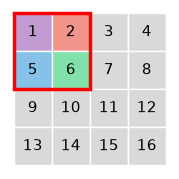

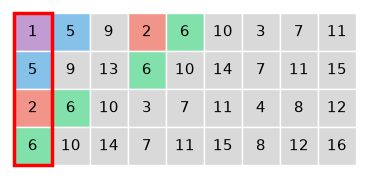

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

# -----------------------------
# Parameters
# -----------------------------
n = 4          # array is n x n
w = 2          # window size
CELL = 0.42    # inches per cell (shared -> equal cell size across figures)

arr = np.arange(1, n*n + 1).reshape(n, n)

# -----------------------------
# Build Hankel-lifted matrix
# -----------------------------
N_x = arr.shape[0] - w + 1
N_y = arr.shape[1] - w + 1
cols = [arr[j:j + w, i:i + w].T.reshape(-1)
        for i in range(N_y) for j in range(N_x)]
data = np.column_stack(cols)

# -----------------------------
# Plotting helper
# -----------------------------
highlight = {1: "#c39bd3", 2: "#f1948a", 5: "#85c1e9", 6: "#82e0aa"}

def draw_matrix(ax, M, boxes=None, default_color="#d9d9d9", fs=11):
    nrows, ncols = M.shape
    for r in range(nrows):
        for c in range(ncols):
            val = int(M[r, c])
            ax.add_patch(
                Rectangle((c, nrows - 1 - r), 1, 1,
                          facecolor=highlight.get(val, default_color),
                          edgecolor="white", linewidth=1.0)
            )
            ax.text(c + 0.5, nrows - 1 - r + 0.5, str(val),
                    ha="center", va="center", fontsize=fs)
    for (bx, by, bw, bh) in (boxes or []):
        ax.add_patch(Rectangle((bx, by), bw, bh, fill=False,
                               edgecolor="red", linewidth=2.5))
    ax.set_xlim(-0.1, ncols + 0.1)
    ax.set_ylim(-0.1, nrows + 0.1)
    ax.set_aspect("equal")
    ax.set_xticks([]); ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)

# -----------------------------
# Render: figure size scales with grid -> equal cell size
# -----------------------------
def save_matrix(M, fname, boxes=None):
    nrows, ncols = M.shape
    fig, ax = plt.subplots(figsize=(ncols * CELL, nrows * CELL),
                           constrained_layout=True)
    draw_matrix(ax, M, boxes=boxes)
    fig.savefig(fname, bbox_inches="tight")
    return fig

save_matrix(arr, "array.pdf", boxes=[(0, arr.shape[0] - w, w, w)])
save_matrix(data, "hankel.pdf", boxes=[(0, 0, 1, data.shape[0])])

plt.show()

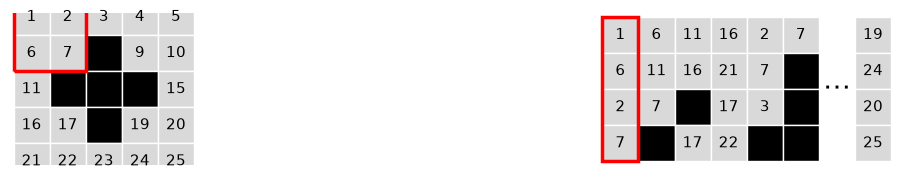

In [35]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

# -----------------------------
# Parameters
# -----------------------------
n = 5
w = 2
CELL = 0.42

arr = np.arange(1, n*n + 1).reshape(n, n)

# -----------------------------
# Build Hankel-lifted matrix
# -----------------------------
N_x = arr.shape[0] - w + 1
N_y = arr.shape[1] - w + 1
cols = [arr[j:j + w, i:i + w].T.reshape(-1)
        for i in range(N_y) for j in range(N_x)]
data = np.column_stack(cols)

highlight = {}
blackout = {8, 13, 18, 12, 14}

def draw_matrix(ax, M, boxes=None, default_color="#d9d9d9", fs=11, y_offset=0.0):
    nrows, ncols = M.shape
    for r in range(nrows):
        for c in range(ncols):
            val = int(M[r, c])
            is_black = val in blackout
            y = nrows - 1 - r + y_offset
            ax.add_patch(
                Rectangle((c, y), 1, 1,
                          facecolor="black" if is_black else highlight.get(val, default_color),
                          edgecolor="white", linewidth=1.0)
            )
            if not is_black:
                ax.text(c + 0.5, y + 0.5, str(val),
                        ha="center", va="center", fontsize=fs)
    for (bx, by, bw, bh) in (boxes or []):
        ax.add_patch(Rectangle((bx, by + y_offset), bw, bh, fill=False,
                               edgecolor="red", linewidth=2.5))
    ax.set_xlim(-0.1, ncols + 0.1)
    ax.set_aspect("equal")
    ax.set_xticks([]); ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)

def draw_matrix_truncated(ax, M, n_first=4, boxes=None,
                          default_color="#d9d9d9", fs=11, gap=1.0, y_offset=0.0):
    """Show first n_first columns, an ellipsis gap, then the last column."""
    nrows, ncols = M.shape
    left_idx = list(range(min(n_first, ncols)))
    show_last = ncols > n_first + 1
    right_idx = [ncols - 1] if show_last else []

    positions = {c: i for i, c in enumerate(left_idx)}
    x_gap_start = len(left_idx)
    for k, c in enumerate(right_idx):
        positions[c] = x_gap_start + gap + k

    for c, x in positions.items():
        for r in range(nrows):
            val = int(M[r, c])
            is_black = val in blackout
            y = nrows - 1 - r + y_offset
            ax.add_patch(
                Rectangle((x, y), 1, 1,
                          facecolor="black" if is_black else highlight.get(val, default_color),
                          edgecolor="white", linewidth=1.0)
            )
            if not is_black:
                ax.text(x + 0.5, y + 0.5, str(val),
                        ha="center", va="center", fontsize=fs)

    total_w = (x_gap_start + gap + len(right_idx)) if show_last else x_gap_start

    if show_last:
        ax.text(x_gap_start + gap / 2, nrows / 2 + y_offset, r"$\cdots$",
                ha="center", va="center", fontsize=fs * 1.8)

    for (bx, by, bw, bh) in (boxes or []):
        ax.add_patch(Rectangle((bx, by + y_offset), bw, bh, fill=False,
                               edgecolor="red", linewidth=2.5))

    ax.set_xlim(-0.1, total_w + 0.1)
    ax.set_aspect("equal")
    ax.set_xticks([]); ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)

# -----------------------------
# Render side by side (empty middle column for the arrow)
# -----------------------------
N_FIRST = 6
GAP = 1.0
hankel_cols_shown = N_FIRST + GAP + 1
MIDDLE = 6.0

# Match figure 2's canvas exactly
max_rows = data.shape[0]
widths = [hankel_cols_shown, MIDDLE, hankel_cols_shown]

fig, axes = plt.subplots(
    1, 3,
    figsize=(sum(widths) * CELL, max_rows * CELL),
    gridspec_kw={"width_ratios": widths},
    constrained_layout=True,
)

# Left panel: enlarge array to full height and anchor at left edge.
arr_offset = (max_rows - arr.shape[0]) / 2
draw_matrix(axes[0], arr, boxes=[(0, arr.shape[0] - w, w, w)], y_offset=arr_offset)
axes[0].set_xlim(-0.1, hankel_cols_shown + 0.1)   # same width as right panel
axes[0].set_ylim(-0.1, max_rows + 0.1)            # same height -> cells scale up

# empty middle axis reserved for a PowerPoint arrow
axes[1].axis("off")

# Right: Hankel at full scale (matches figure 2)
data_offset = 0.0
draw_matrix_truncated(axes[2], data, n_first=N_FIRST,
                      boxes=[(0, 0, 1, data.shape[0])], gap=GAP, y_offset=data_offset)
axes[2].set_ylim(-0.1, max_rows + 0.1)

fig.savefig("array_vs_hankel.pdf", bbox_inches="tight")
plt.show()

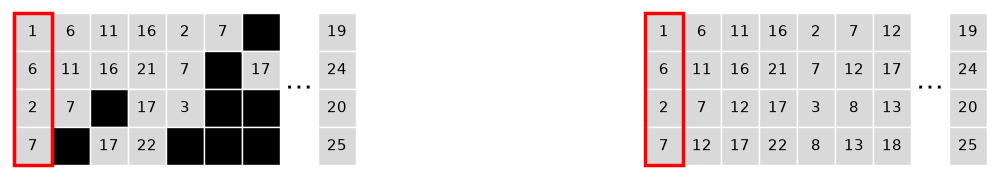

In [34]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

# -----------------------------
# Parameters
# -----------------------------
n = 5
w = 2
CELL = 0.42

arr = np.arange(1, n*n + 1).reshape(n, n)

# -----------------------------
# Build Hankel-lifted matrix
# -----------------------------
N_x = arr.shape[0] - w + 1
N_y = arr.shape[1] - w + 1
cols = [arr[j:j + w, i:i + w].T.reshape(-1)
        for i in range(N_y) for j in range(N_x)]
data = np.column_stack(cols)

highlight = {}
blackout = {8, 13, 18, 12, 14}

def draw_matrix_truncated(ax, M, n_first=4, boxes=None,
                          default_color="#d9d9d9", fs=11, gap=1.0, y_offset=0.0,
                          blackout_set=None):
    """Show first n_first columns, an ellipsis gap, then the last column."""
    if blackout_set is None:
        blackout_set = set()
    nrows, ncols = M.shape
    left_idx = list(range(min(n_first, ncols)))
    show_last = ncols > n_first + 1
    right_idx = [ncols - 1] if show_last else []

    positions = {c: i for i, c in enumerate(left_idx)}
    x_gap_start = len(left_idx)
    for k, c in enumerate(right_idx):
        positions[c] = x_gap_start + gap + k

    for c, x in positions.items():
        for r in range(nrows):
            val = int(M[r, c])
            is_black = val in blackout_set
            y = nrows - 1 - r + y_offset
            ax.add_patch(
                Rectangle((x, y), 1, 1,
                          facecolor="black" if is_black else highlight.get(val, default_color),
                          edgecolor="white", linewidth=1.0)
            )
            if not is_black:
                ax.text(x + 0.5, y + 0.5, str(val),
                        ha="center", va="center", fontsize=fs)

    total_w = (x_gap_start + gap + len(right_idx)) if show_last else x_gap_start

    if show_last:
        ax.text(x_gap_start + gap / 2, nrows / 2 + y_offset, r"$\cdots$",
                ha="center", va="center", fontsize=fs * 1.8)

    for (bx, by, bw, bh) in (boxes or []):
        ax.add_patch(Rectangle((bx, by + y_offset), bw, bh, fill=False,
                               edgecolor="red", linewidth=2.5))

    ax.set_xlim(-0.1, total_w + 0.1)
    ax.set_aspect("equal")
    ax.set_xticks([]); ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)

# -----------------------------
# Render side by side (empty middle column for the arrow)
# -----------------------------
N_FIRST = 7
GAP = 1.0
hankel_cols_shown = N_FIRST + GAP + 1
MIDDLE = 6.0

max_rows = data.shape[0]
widths = [hankel_cols_shown, MIDDLE, hankel_cols_shown]

fig, axes = plt.subplots(
    1, 3,
    figsize=(sum(widths) * CELL, max_rows * CELL),
    gridspec_kw={"width_ratios": widths},
    constrained_layout=True,
)

data_offset = (max_rows - data.shape[0]) / 2

# Left: Hankel WITH blacked-out numbers
draw_matrix_truncated(axes[0], data, n_first=N_FIRST,
                      boxes=[(0, 0, 1, data.shape[0])], gap=GAP, y_offset=data_offset,
                      blackout_set=blackout)
axes[0].set_ylim(-0.1, max_rows + 0.1)

# empty middle axis reserved for a PowerPoint arrow
axes[1].axis("off")

# Right: same Hankel with NOTHING blacked out
draw_matrix_truncated(axes[2], data, n_first=N_FIRST,
                      boxes=[(0, 0, 1, data.shape[0])], gap=GAP, y_offset=data_offset,
                      blackout_set=set())
axes[2].set_ylim(-0.1, max_rows + 0.1)

fig.savefig("hankel_blackout_vs_full.pdf", bbox_inches="tight")
plt.show()

In [5]:
# central 3x3 block of the 7x7 array → values 17,18,19, 24,25,26, 31,32,33
black_cells = {17, 18, 19, 24, 25, 26, 31, 32, 33}

def draw_matrix(ax, M, title, default_color="#d9d9d9", boxes=None):
    nrows, ncols = M.shape

    for r in range(nrows):
        for c in range(ncols):
            val = int(M[r, c])
            if val in black_cells:
                facecolor = "black"
            else:
                facecolor = highlight.get(val, default_color)

            ax.add_patch(
                Rectangle((c, nrows - 1 - r), 1, 1,
                          facecolor=facecolor, edgecolor="white", linewidth=1.0)
            )

            # skip text on black cells (or make it white)
            if val not in black_cells:
                ax.text(c + 0.5, nrows - 1 - r + 0.5, str(val),
                        ha="center", va="center", fontsize=13)

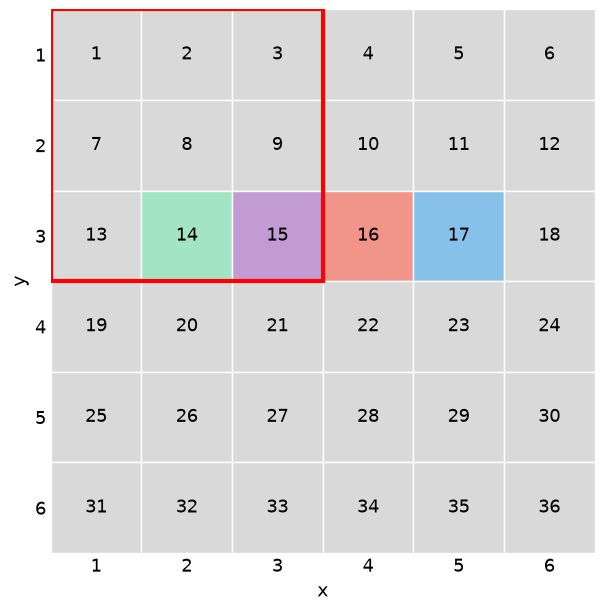

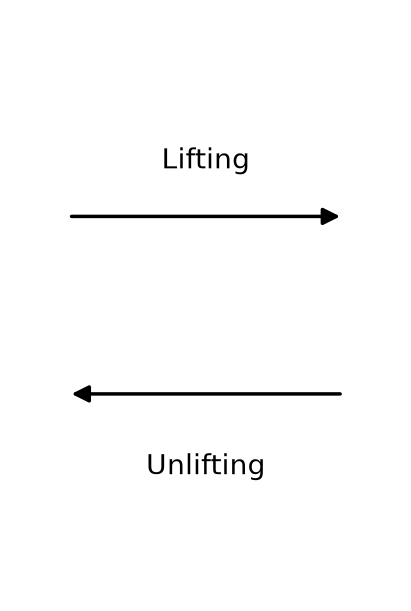

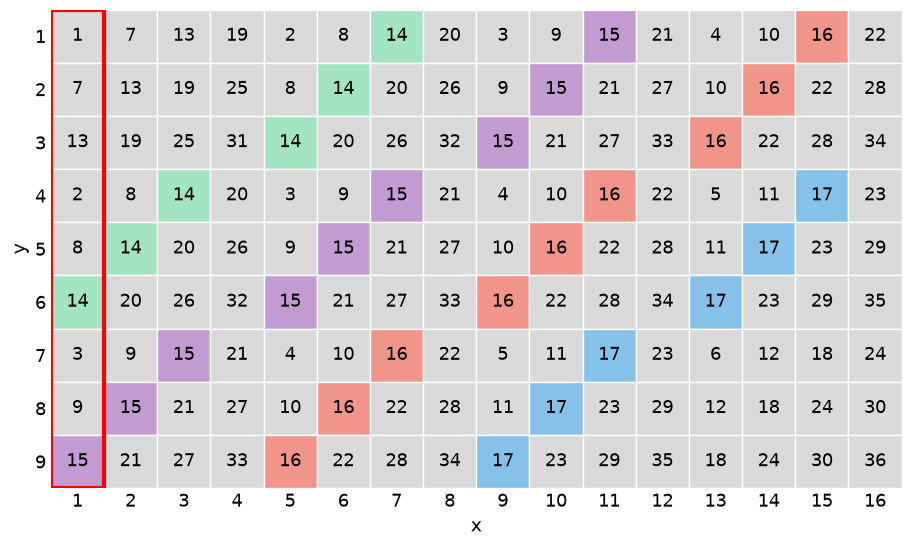

In [20]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Rectangle

# -----------------------------
# Build original array
# -----------------------------
arr = np.arange(1, 37).reshape(6, 6)

# -----------------------------
# Build Hankel-lifted matrix
# -----------------------------
w = 3
data = np.empty((w * w, 0), dtype=int)

N_x = arr.shape[0] - w + 1
N_y = arr.shape[1] - w + 1

x = 0
y = 0

for i in range(N_y):
    for j in range(N_x):
        mat = arr[x:x + w, y:y + w]
        col = mat.T.reshape(-1)
        data = np.column_stack((data, col))
        x += 1
    x = 0
    y += 1

# -----------------------------
# Plotting helper
# -----------------------------
highlight = {
    14:  "#a3e4c2",
    15:  "#c39bd3",
    16:  "#f1948a",
    17:  "#85c1e9"
}

def draw_matrix(ax, M, default_color="#d9d9d9", boxes=None):
    nrows, ncols = M.shape

    for r in range(nrows):
        for c in range(ncols):
            val = int(M[r, c])
            facecolor = highlight.get(val, default_color)

            ax.add_patch(
                Rectangle((c, nrows - 1 - r), 1, 1,
                          facecolor=facecolor, edgecolor="white", linewidth=1.0)
            )

            ax.text(
                c + 0.5,
                nrows - 1 - r + 0.5,
                str(val),
                ha="center",
                va="center",
                fontsize=13
            )

    # draw red highlight boxes: (x0, y0, width, height) in cell coordinates
    if boxes:
        for (bx, by, bw, bh) in boxes:
            ax.add_patch(
                Rectangle((bx, by), bw, bh,
                          fill=False, edgecolor="red", linewidth=3.0)
            )

    ax.set_xlim(0, ncols)
    ax.set_ylim(0, nrows)
    ax.set_aspect("equal")

    ax.set_xticks(np.arange(ncols) + 0.5)
    ax.set_xticklabels(np.arange(1, ncols + 1), fontsize=13)
    ax.set_yticks(np.arange(nrows) + 0.5)
    ax.set_yticklabels(np.arange(nrows, 0, -1), fontsize=13)

    ax.tick_params(length=0)
    ax.set_xlabel("x", fontsize=14)
    ax.set_ylabel("y", fontsize=14)

    for spine in ax.spines.values():
        spine.set_visible(False)

# =============================
# Figure 1: Original array
# =============================
fig1, ax1 = plt.subplots(figsize=(6, 6), constrained_layout=True)
draw_matrix(ax1, arr, boxes=[(0, arr.shape[0] - 3, 3, 3)])
# fig1.savefig("original_array.png", dpi=600, bbox_inches="tight")
fig1.savefig("original_array.pdf", bbox_inches="tight")

# =============================
# Figure 2: Lifting/Unlifting arrows
# =============================
fig2, ax2 = plt.subplots(figsize=(4, 6), constrained_layout=True)
ax2.axis("off")

# lifting arrow (left -> right)
ax2.add_patch(mpatches.FancyArrowPatch(
    (0.15, 0.65), (0.85, 0.65),
    transform=ax2.transAxes,
    arrowstyle="-|>", mutation_scale=25,
    linewidth=2.5, color="black"
))
ax2.text(0.5, 0.72, "Lifting", ha="center", va="bottom",
         fontsize=20, transform=ax2.transAxes)

# unlifting arrow (right -> left)
ax2.add_patch(mpatches.FancyArrowPatch(
    (0.85, 0.35), (0.15, 0.35),
    transform=ax2.transAxes,
    arrowstyle="-|>", mutation_scale=25,
    linewidth=2.5, color="black"
))
ax2.text(0.5, 0.25, "Unlifting", ha="center", va="top",
         fontsize=20, transform=ax2.transAxes)
# fig2.savefig("lifting_arrows.png", dpi=600, bbox_inches="tight")
fig2.savefig("lifting_arrows.pdf", bbox_inches="tight")

# =============================
# Figure 3: Hankel matrix
# =============================
fig3, ax3 = plt.subplots(figsize=(9, 6), constrained_layout=True)
draw_matrix(ax3, data, boxes=[(0, 0, 1, data.shape[0])])
# fig3.savefig("hankel_matrix.png", dpi=600, bbox_inches="tight")
fig3.savefig("hankel_matrix.pdf", bbox_inches="tight")

Reconstruction close to original: False


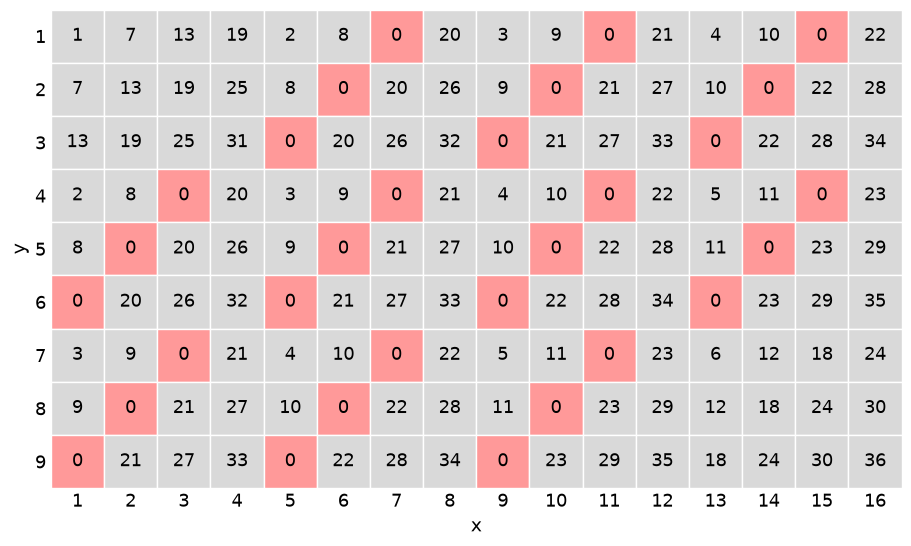

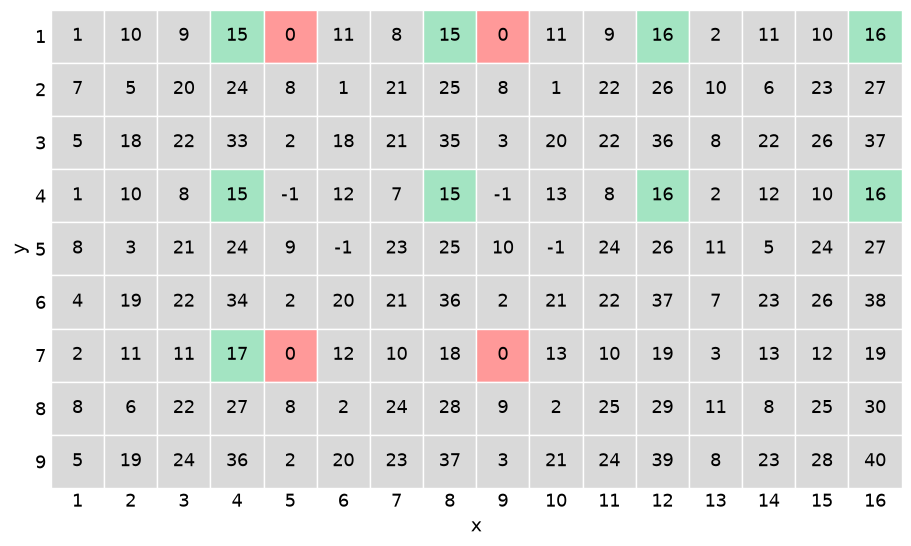

In [55]:
# =============================
# SVD + reconstruction of Hankel matrix
# =============================
arr = np.arange(1, 37).reshape(6, 6)
arr[2, 1:5] = 0
highlight = {
    14:  "#a3e4c2",
    15:  "#a3e4c2",
    16:  "#a3e4c2",
    17:  "#a3e4c2"
}
highlight[0] = "#ff9999"

w = 3
data = np.empty((w * w, 0), dtype=int)
N_x = arr.shape[0] - w + 1
N_y = arr.shape[1] - w + 1

x = y = 0
for i in range(N_y):
    for j in range(N_x):
        mat = arr[x:x + w, y:y + w]
        col = mat.T.reshape(-1)
        data = np.column_stack((data, col))
        x += 1
    x = 0
    y += 1

U, S_reduced, Vh = asm.sig_val_thresholding_jax(data, 0.2)
data_recon = (U * S_reduced) @ Vh
data_recon = np.round((U * S_reduced) @ Vh).astype(int)

print("Reconstruction close to original:", np.allclose(data, data_recon))

# =============================
# Figure 4: data (Hankel) and data_recon
# =============================
def draw_matrix_float(ax, M, default_color="#d9d9d9", boxes=None, fmt="{:.0f}"):
    nrows, ncols = M.shape
    for r in range(nrows):
        for c in range(ncols):
            val = M[r, c]
            facecolor = highlight.get(int(round(val)), default_color)
            ax.add_patch(
                Rectangle((c, nrows - 1 - r), 1, 1,
                          facecolor=facecolor, edgecolor="white", linewidth=1.0)
            )
            ax.text(c + 0.5, nrows - 1 - r + 0.5, fmt.format(val),
                    ha="center", va="center", fontsize=13)

    if boxes:
        for (bx, by, bw, bh) in boxes:
            ax.add_patch(Rectangle((bx, by), bw, bh,
                         fill=False, edgecolor="red", linewidth=3.0))

    ax.set_xlim(0, ncols)
    ax.set_ylim(0, nrows)
    ax.set_aspect("equal")
    ax.set_xticks(np.arange(ncols) + 0.5)
    ax.set_xticklabels(np.arange(1, ncols + 1), fontsize=13)
    ax.set_yticks(np.arange(nrows) + 0.5)
    ax.set_yticklabels(np.arange(nrows, 0, -1), fontsize=13)
    ax.tick_params(length=0)
    ax.set_xlabel("x", fontsize=14)
    ax.set_ylabel("y", fontsize=14)
    for spine in ax.spines.values():
        spine.set_visible(False)

fig4, ax4 = plt.subplots(figsize=(9, 6), constrained_layout=True)
draw_matrix_float(ax4, data)
#fig4.savefig("hankel_data.pdf", bbox_inches="tight")

fig5, ax5 = plt.subplots(figsize=(9, 6), constrained_layout=True)
draw_matrix_float(ax5, data_recon)
fig5.savefig("hankel_data_recon.pdf", bbox_inches="tight")

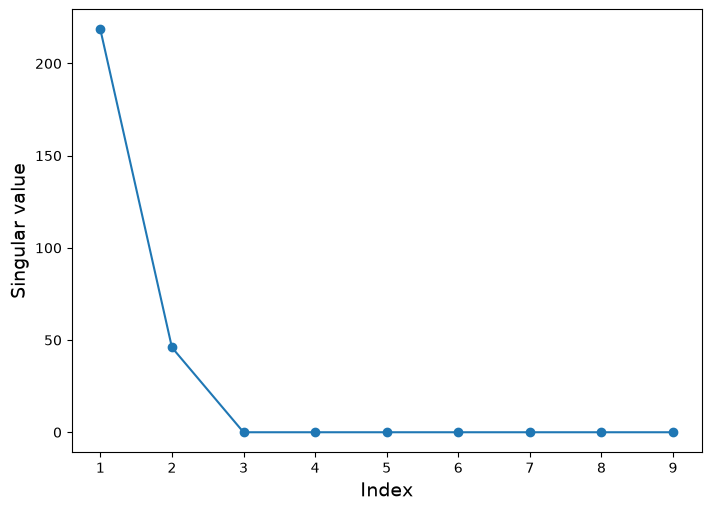

In [45]:
fig6, ax6 = plt.subplots(figsize=(7, 5), constrained_layout=True)
ax6.plot(np.arange(1, len(S_reduced) + 1), S_reduced, marker="o")
ax6.set_xlabel("Index", fontsize=14)
ax6.set_ylabel("Singular value", fontsize=14)
#ax6.set_title("Singular value spectrum of S_reduced", fontsize=14)
fig6.savefig("singular_spectrum.pdf", bbox_inches="tight")

U: (9, 9) Sigma: (9, 9) Vh: (16, 16)


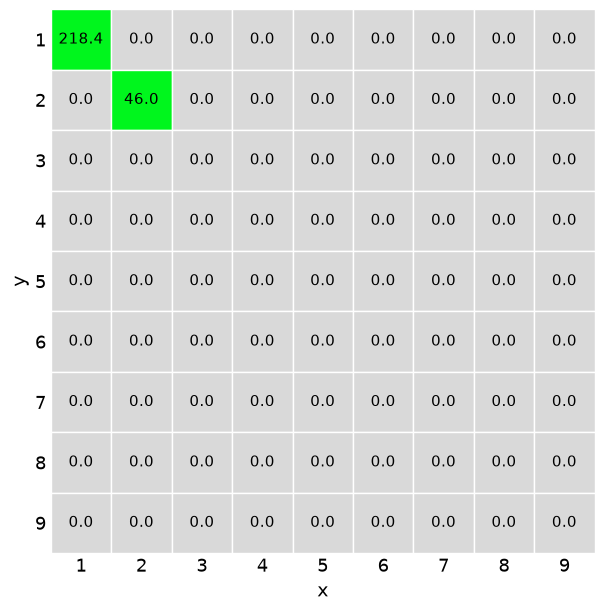

In [49]:
# =============================
# SVD of Hankel matrix
# =============================
U, S, Vh = np.linalg.svd(data, full_matrices=True)
Sigma = np.diag(S_reduced)

print("U:", U.shape, "Sigma:", Sigma.shape, "Vh:", Vh.shape)

# =============================
# Styling helper (float values, no value-based highlight)
# =============================
def draw_matrix_float(ax, M, default_color="#d9d9d9", highlight_color="#00f61d",
                      fmt="{:.1f}", fontsize=11):
    nrows, ncols = M.shape
    for r in range(nrows):
        for c in range(ncols):
            val = M[r, c]
            facecolor = highlight_color if abs(val) > 1e-8 else default_color
            ax.add_patch(
                Rectangle((c, nrows - 1 - r), 1, 1,
                          facecolor=facecolor, edgecolor="white", linewidth=1.0)
            )
            ax.text(c + 0.5, nrows - 1 - r + 0.5, fmt.format(val),
                    ha="center", va="center", fontsize=fontsize)

    ax.set_xlim(0, ncols)
    ax.set_ylim(0, nrows)
    ax.set_aspect("equal")
    ax.set_xticks(np.arange(ncols) + 0.5)
    ax.set_xticklabels(np.arange(1, ncols + 1), fontsize=13)
    ax.set_yticks(np.arange(nrows) + 0.5)
    ax.set_yticklabels(np.arange(nrows, 0, -1), fontsize=13)
    ax.tick_params(length=0)
    ax.set_xlabel("x", fontsize=14)
    ax.set_ylabel("y", fontsize=14)
    for spine in ax.spines.values():
        spine.set_visible(False)

# =============================
# Figure: Sigma
# =============================
figS, axS = plt.subplots(figsize=(6, 6), constrained_layout=True)
draw_matrix_float(axS, Sigma, fmt="{:.1f}")
figS.savefig("svd_Sigma.pdf", bbox_inches="tight")

In [7]:
def onecoil_hankel(kspace, w):
    y = 0
    x = 0
    N_x = kspace.shape[0] - w + 1 
    N_y = kspace.shape[1] - w + 1
    data_matrix = np.empty((w*w,0))
    for i in range(N_y):        
        for j in range(N_x):    
            mat = kspace[x:x+w, y:y+w]
            col = mat.T.reshape(-1)
            data_matrix = np.column_stack((data_matrix, col))
            x += 1
        x = 0
        y += 1
    return(data_matrix)

data = onecoil_hankel(arr, 3)

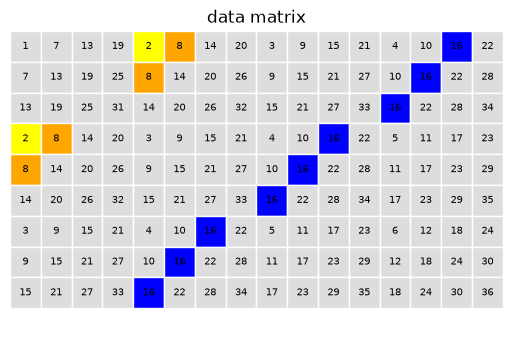

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches


special = {2: 'yellow', 8: 'orange', 16: 'blue'}

fig, ax = plt.subplots(figsize=(10, 4))

ax.set_title('data matrix')
for r in range(data.shape[0]):
    for c in range(data.shape[1]):
        v = int(data[r, c])
        ax.add_patch(plt.Rectangle((c, -r), 1, 1, color=special.get(v, '#ddd'), ec='white'))
        ax.text(c+0.5, -r+0.5, str(v), ha='center', va='center', fontsize=7)
ax.set_xlim(0, data.shape[1])
ax.set_ylim(-data.shape[0], 1)
ax.set_aspect('equal')
ax.axis('off')

plt.show()


In [9]:
arr = np.arange(1, 109).reshape(3, 6, 6)
def hankel(kspace, w):
    x = 0
    y = 0
    c = 0
    N_x = kspace.shape[1] - w + 1 
    N_y = kspace.shape[2] - w + 1
    N_c = kspace.shape[0]
    data_matrix = []
    for k in range(N_c):
        onecoil_matrix = np.empty((w*w,0))
        for i in range(N_y):        
            for j in range(N_x):    
                mat = kspace[c,x:x+w, y:y+w]
                col = mat.T.reshape(-1)
                onecoil_matrix = np.column_stack((onecoil_matrix, col))
                x += 1
            x = 0
            y += 1
        data_matrix.append(onecoil_matrix)
        y = 0
        c += 1
    return(np.vstack(data_matrix), N_c, N_x, N_y)

data, n_coils, N_x, N_y = hankel(arr, 3)

In [10]:
split_arr = np.array(np.split(data, 3))
split_test = split_arr[0]
kspace = []
Nx = 6
Ny = 6

num_x_wins = Nx - w + 1
num_y_wins = Ny - w + 1

for i in range(len(split_arr)):
    split_test = split_arr[i]
    split_test = split_test.T
    windows = []
    for j in range(split_test.shape[0]):
        window = split_test[j]
        #print(f"window:{window}")
        window = split_test[j].reshape(w,w)
        #print(f"window:{window}")
        windows.append(window)
        windows_full = np.array(windows)


    recon = np.zeros((Nx, Ny))
    w = 3

    for index, win in enumerate(windows_full): 
        i = (index // num_x_wins) * 1
        j = (index % num_y_wins) * 1

        recon[i:i+w, j:j+w] = win
        #print(recon)

    kspace.append(recon.T)

print(np.array(kspace))

[[[  1.   2.   3.   4.   5.   6.]
  [  7.   8.   9.  10.  11.  12.]
  [ 13.  14.  15.  16.  17.  18.]
  [ 19.  20.  21.  22.  23.  24.]
  [ 25.  26.  27.  28.  29.  30.]
  [ 31.  32.  33.  34.  35.  36.]]

 [[ 37.  38.  39.  40.  41.  42.]
  [ 43.  44.  45.  46.  47.  48.]
  [ 49.  50.  51.  52.  53.  54.]
  [ 55.  56.  57.  58.  59.  60.]
  [ 61.  62.  63.  64.  65.  66.]
  [ 67.  68.  69.  70.  71.  72.]]

 [[ 73.  74.  75.  76.  77.  78.]
  [ 79.  80.  81.  82.  83.  84.]
  [ 85.  86.  87.  88.  89.  90.]
  [ 91.  92.  93.  94.  95.  96.]
  [ 97.  98.  99. 100. 101. 102.]
  [103. 104. 105. 106. 107. 108.]]]


In [11]:
def hankel_H(data_matrix, n_coils, Nx, Ny, w=3):
    kspace = []
    split_arr = np.array(np.split(data_matrix, n_coils))

    n_win_x = Nx - w + 1
    n_win_y = Ny - w + 1

    for k in range(len(split_arr)):
        #n_windows = split_arr.shape[1]

        singlecol = split_arr[k]
        transposed = singlecol.T
        #print(singlecol)
        #print(transposed)
        windows = []
        for j in range(len(transposed)):
            window = transposed[j].reshape(w,w)
            windows.append(window)
            windows_full = np.array(windows)
            

        
        recon = np.zeros((Nx, Ny))

        for index, win in enumerate(windows_full): 
            row = (index // n_win_y)
            col = (index % n_win_y)
            i = row
            j = col
            recon[i:i+w, j:j+w] = win
        kspace.append(recon.T)
    return(np.array(kspace))

In [12]:
arr1 = np.arange(1, 109).reshape(3, 6, 6)

data_arr, N_c, N_x, N_y = asm.hankel(arr, 5)

arr2 = asm.hankel_H_averaged(data_arr, N_c, Nx=6, Ny=6, w=5)

In [13]:
np.allclose(arr1, arr2, rtol=0, atol=0)

True

In [14]:
def sig_val_thresholding(data, zero_thresh):
    U, Sigma, Vh = np.linalg.svd(data, full_matrices=False)
    max_val = np.max(Sigma)
    thresh = max_val*zero_thresh
    arr = []
    for i in range(len(Sigma)):
        if Sigma[i] > thresh:
            arr.append(Sigma[i])
        else: arr.append(0)
    S_reduced = np.array(arr)
    return(U, S_reduced, Vh)

def svd_recon(u, s_reduced, vh):
    return u @ np.diag(s_reduced) @ vh